In [1]:
import duckdb
import pandas as pd
# we use np.random for the simulation randomness
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

project_root = Path("..")
cleaned_dir = project_root / "data" / "cleaned"
raw_dir = project_root / "data" / "raw"

# open a mini SQL database session inside Python using duckdb, 
# which allows us to run SQL queries directly on our parquet files 
# without needing to load everything into memory at once
con = duckdb.connect()

fuel_cost_per_mile = 0.20


# ------------------------------------------------------------
# 1. Zone-hour trip statistics
# ------------------------------------------------------------

# part 1 answers: what is a typical trip like if I start in zone i at hour h?

# goal of part 1 is to get number of trips, average net earnings and 
# trip duration by pickup zone and hour, 
# which will be used in the simulation later
# zone_hour_stats will be a dataframe with one row per pickup zone and hour, 
# and columns for the stats we need
zone_hour_stats = con.execute(f"""
SELECT
    t.PULocationID,
    EXTRACT(hour FROM tpep_pickup_datetime) AS pickup_hour,
    z.Borough,
    z.Zone,
    COUNT(*) AS trips,

    AVG(total_amount - {fuel_cost_per_mile} * trip_distance)
        AS avg_net_trip_earnings,

    AVG(
        EXTRACT(EPOCH FROM (tpep_dropoff_datetime - tpep_pickup_datetime)) / 60.0
    ) AS avg_trip_minutes

FROM read_parquet('{cleaned_dir}/yellow_tripdata_2024-*.parquet') t

LEFT JOIN read_csv_auto('{raw_dir}/taxi_zone_lookup.csv') z
    ON t.PULocationID = z.LocationID

-- keep only trips that start between 8 AM and 8 PM
-- because I want to simulate 8-hour shifts starting at 8 AM or 12 PM
WHERE
    total_amount > 0
    AND z.Borough != 'EWR'

GROUP BY
    t.PULocationID,
    pickup_hour,
    z.Borough,
    z.Zone

HAVING COUNT(*) >= 100
""").fetchdf()


# ------------------------------------------------------------
# 2. Zone-hour transitions
# ------------------------------------------------------------

# part 2 answers: where do trips from zone i at hour h typically go?
# zone_hour_transitions is a table with one row per pickup zone, hour, and dropoff zone
# it's not yet a probability table, just counts of trips, but we'll convert it to probabilities later

zone_hour_transitions = con.execute(f"""
SELECT
    PULocationID,
    DOLocationID,
    EXTRACT(hour FROM tpep_pickup_datetime) AS pickup_hour,
    COUNT(*) AS trips

FROM read_parquet('{cleaned_dir}/yellow_tripdata_2024-*.parquet')

WHERE
    total_amount > 0

GROUP BY
    PULocationID,
    DOLocationID,
    pickup_hour
""").fetchdf()


# ------------------------------------------------------------
# 3. Restrict to zones with enough data
# ------------------------------------------------------------

# 3 restricts the model to zones with enough data,
# and converts the transition counts to probabilities

# we want to keep zones that have at least 1000 trips in the zone_hour_stats table,
# which should give us enough data to have reliable estimates of the stats and transitions
# this creates a list-like object containiing the zone IDs that meet the threshold
valid_zones = (
    zone_hour_stats.groupby("PULocationID")["trips"]
    # sum all the trips for each pickup zone across all hours to get total trips per zone
    .sum()
    # filter to keep only zones with at least 1000 total trips
    # take the series produced by the previous step
    # call it x, and keep only the values where x >= 1000
    .loc[lambda x: x >= 1000]
    # get the index of the resulting series, which are the valid zone IDs
    .index
)

# filter the zone_hour_stats and zone_hour_transitions tables to keep only rows 
# where the pickup zone is in the valid_zones list
zone_hour_stats = zone_hour_stats[
    zone_hour_stats["PULocationID"].isin(valid_zones)
]

zone_hour_transitions = zone_hour_transitions[
    zone_hour_transitions["PULocationID"].isin(valid_zones)
]

zone_hour_transitions = zone_hour_transitions[
    zone_hour_transitions["DOLocationID"].isin(valid_zones)
]

# this converts the trip counts in zone_hour_transitions to probabilities 
# by dividing each row's trip count by the total trips for that pickup zone and hour
zone_hour_transitions["transition_prob"] = (
    zone_hour_transitions["trips"] /
    zone_hour_transitions.groupby(
        ["PULocationID","pickup_hour"]
    )["trips"].transform("sum")
)


# ------------------------------------------------------------
# 4. Improved wait-time proxy using pickups and dropoffs
# ------------------------------------------------------------

# goal of part 4 is to create a df zone_hour_flows that contains, for each zone and hour, 
# the total pickups, total dropoffs, ratio of dropoffs to pickups,
# and a proxy for expected wait time in minutes based on the ratio of dropoffs to pickups

# first create a new table that aggregates pickups and dropoffs by zone and hour
zone_hour_flows = con.execute(f"""
SELECT
    zone_id,
    hour,
    SUM(pickups) AS pickups,
    SUM(dropoffs) AS dropoffs
FROM (

    SELECT
        PULocationID AS zone_id,
        EXTRACT(hour FROM tpep_pickup_datetime) AS hour,
        COUNT(*) AS pickups,
        0 AS dropoffs
    FROM read_parquet('{cleaned_dir}/yellow_tripdata_2024-*.parquet')
    WHERE
        total_amount > 0
    GROUP BY
        PULocationID,
        hour

    UNION ALL

    SELECT
        DOLocationID AS zone_id,
        EXTRACT(hour FROM tpep_dropoff_datetime) AS hour,
        0 AS pickups,
        COUNT(*) AS dropoffs
    FROM read_parquet('{cleaned_dir}/yellow_tripdata_2024-*.parquet')
    WHERE
        total_amount > 0
    GROUP BY
        DOLocationID,
        hour

)
GROUP BY
    zone_id,
    hour
""").fetchdf()

# filter to keep only valid zones that have enough data, which we identified earlier
zone_hour_flows = zone_hour_flows[
    zone_hour_flows["zone_id"].isin(valid_zones)
].copy()

# avoid divide-by-zero
# because we later calculate dropoffs / pickups, we need to make sure pickups is never zero
# this line says if pickups less than 1, set it to 1, otherwise keep it as is
zone_hour_flows["pickups"] = zone_hour_flows["pickups"].clip(lower=1)

# more dropoffs relative to pickups means more taxi competition
zone_hour_flows["dropoff_pickup_ratio"] = (
    zone_hour_flows["dropoffs"] / zone_hour_flows["pickups"]
)

# scaling constant in minutes
wait_scale = 5.0

# the ratio dropoffs / pickups is unitless, so to turn it into minutes 
# we multiply by a scaling constant, which we set to 5 minutes here
zone_hour_flows["expected_wait_minutes"] = (
    wait_scale * zone_hour_flows["dropoff_pickup_ratio"]
)

# keep values in a realistic range of 1 to 30 minutes, to avoid extreme values dominating the simulation
zone_hour_flows["expected_wait_minutes"] = (
    zone_hour_flows["expected_wait_minutes"].clip(lower=1, upper=30)
)

zone_hour_flows.head()


# ------------------------------------------------------------
# 5. Build lookup dictionaries
# ------------------------------------------------------------

# part 5 builds lookup dictionaries from the dataframes we created, 
# which will allow us to quickly access the stats, transitions, and wait times 
# for any given zone and hour during the simulation without needing to do slow dataframe lookups

# given a zone and hour, tell me
# average net earnings for trips starting in that zone and hour
# average trip duration for trips starting in that zone and hour
# zone name and borough for that zone, which we can use for labeling results later
# start with an empty dictionary, and then loop through each row of the zone_hour_stats dataframe
stats_lookup = {}
# _ is the row index, which we don't need, and row is the actual data for that row as a Series
for _, row in zone_hour_stats.iterrows():
    # [(int(row["PULocationID"]), int(row["pickup_hour"]))] is a tuple (zone_id, hour) 
    # that we use as the key in the stats_lookup dictionary
    stats_lookup[(int(row["PULocationID"]), int(row["pickup_hour"]))] = {
        "avg_net_trip_earnings": float(row["avg_net_trip_earnings"]),
        "avg_trip_minutes": float(row["avg_trip_minutes"]),
        "zone_name": row["Zone"],
        "borough": row["Borough"],
    }

# given a zone and hour, tell me the possible destination zones,
# and the probabilities of transitioning to each destination zone based on the historical data
transitions_lookup = {}
# each group is a subset of the zone_hour_transitions dataframe 
# that corresponds to a specific pickup zone and hour
for (pu, hr), group in zone_hour_transitions.groupby(["PULocationID", "pickup_hour"]):
    # extract destination zone IDs as numpy array of integers
    destinations = group["DOLocationID"].astype(int).to_numpy()
    # extract transition probabilities as numpy array of floats
    probabilities = group["transition_prob"].to_numpy(dtype=float)
    # make sure probabilities sum to 1, which is important for the random choice in the simulation
    probabilities = probabilities / probabilities.sum()

    # dictionary uses integer keys for zone and hour
    # but when pandas reads data from duckdb, it might read them as floats, 
    # so we convert to int just to be safe
    transitions_lookup[(int(pu), int(hr))] = {
        "destinations": destinations,
        "probabilities": probabilities,
    }

# given a zone and hour, tell me the expected wait time
wait_lookup = {}
for _, row in zone_hour_flows.iterrows():
    wait_lookup[(int(row["zone_id"]), int(row["hour"]))] = float(row["expected_wait_minutes"])

print("stats keys:", len(stats_lookup))
print("transition keys:", len(transitions_lookup))
print("wait keys:", len(wait_lookup))



# ------------------------------------------------------------
# 6. Simulation
# ------------------------------------------------------------

# this simulates an 8-hour shift starting in a given zone and hour,
# and returns the net earnings per hour and total trip count for that shift
def simulate_shift(start_zone, start_hour, shift_minutes=480, rng=None):

    # random number generator for reproducibility, 
    # we can pass in a specific rng with a fixed seed for consistent results across runs
    if rng is None:
        rng = np.random.default_rng()

    current_zone = int(start_zone)

    elapsed_minutes = 0
    total_net_earnings = 0
    trip_count = 0

    # initial waiting time before the first ride
    initial_hour = start_hour % 24
    initial_wait = wait_lookup.get((current_zone, initial_hour), 5)
    elapsed_minutes += initial_wait

    while elapsed_minutes < shift_minutes:

        current_hour = (start_hour + int(elapsed_minutes / 60)) % 24

        stats_key = (current_zone, current_hour)
        trans_key = (current_zone, current_hour)

        if stats_key not in stats_lookup:
            break

        if trans_key not in transitions_lookup:
            break

        trip_stats = stats_lookup[stats_key]

        trip_minutes = trip_stats["avg_trip_minutes"]

        # if zone hour is missing, model assumes a default wait time of 5 minutes before the next trip, 
        # which is a simple way to handle missing data without crashing the simulation
        wait_minutes = wait_lookup.get(
            (current_zone, current_hour),
            5
        )

        total_net_earnings += trip_stats["avg_net_trip_earnings"]

        elapsed_minutes += trip_minutes + wait_minutes

        trip_count += 1

        destinations = transitions_lookup[trans_key]["destinations"]
        probabilities = transitions_lookup[trans_key]["probabilities"]

        # randomly select the next zone
        current_zone = int(
            rng.choice(destinations, p=probabilities)
        )

    hours_worked = elapsed_minutes / 60

    if hours_worked <= 0:
        return {
            "net_earnings_per_hour": np.nan,
            "trip_count": 0
        }
    
    if trip_count == 0:
        return {
            "net_earnings_per_hour": np.nan,
            "trip_count": 0
        }

    # the function returns a dictionary with the net earnings per hour 
    # and total trip count for the simulated shift
    return {
        "net_earnings_per_hour": total_net_earnings / hours_worked,
        "trip_count": trip_count
    }

# Monte Carlo simulation to evaluate the expected net earnings per hour for starting in each zone at 8 AM,
# by running multiple simulations and averaging the results
def evaluate_start_zone(start_zone, start_hour, n_simulations=200, seed=123):

    # create a list to store the net earnings per hour results from each simulation run
    results = []

    # use a seed because it makes the simulation reproducible
    rng = np.random.default_rng(seed)

    # _ means we don't care about the loop index, we just want to run the loop n_simulations times
    for _ in range(n_simulations):

        sim = simulate_shift(
            start_zone=start_zone,
            start_hour=start_hour,
            rng=rng
        )

        results.append(sim["net_earnings_per_hour"])

    # compute the expected earnings, as well as how much the simulated earnings vary across runs, 
    # which gives us a sense of the riskiness of starting in that zone
    return np.nanmean(results), np.nanstd(results)



# ------------------------------------------------------------
# 7. Evaluate zones
# ------------------------------------------------------------

# this loops through each valid zone, runs the simulation to get the expected 
# net earnings per hour and standard deviation for that zone,
# and then looks up the zone name and borough for labeling the results later

zone_hour_results = []

for start_hour in range(24):

    print("Evaluating start hour:", start_hour)

    for zone_id in sorted(valid_zones):

        mean_eph, std_eph = evaluate_start_zone(
            start_zone=zone_id,
            start_hour=start_hour,
            n_simulations=200,
            seed = 123 + 1000 * start_hour + zone_id
        )

        zone_name = zone_hour_stats.loc[
            zone_hour_stats.PULocationID == zone_id,
            "Zone"
        ].iloc[0]

        borough = zone_hour_stats.loc[
            zone_hour_stats.PULocationID == zone_id,
            "Borough"
        ].iloc[0]

        zone_hour_results.append({
            "start_hour": start_hour,
            "PULocationID": zone_id,
            "Zone": zone_name,
            "Borough": borough,
            "expected_net_earnings_per_hour": mean_eph,
            "std_net_earnings_per_hour": std_eph
        })

zone_hour_results = pd.DataFrame(zone_hour_results)

# becauze zone_hour_stats requires having count(*) >=100
# some late-night hourrs may have no stats_lookup
# let's quantify this

zone_hour_results["is_missing"] = zone_hour_results["expected_net_earnings_per_hour"].isna()

zone_hour_results.groupby("start_hour")["expected_net_earnings_per_hour"].apply(lambda x: x.isna().mean())

zone_hour_results = zone_hour_results.sort_values(
    "expected_net_earnings_per_hour",
    ascending=False
)

zone_hour_results.head(10)

stats keys: 3687
transition keys: 4536
wait keys: 4536
Evaluating start hour: 0


/var/folders/g_/k3hv7kv12p37yjw1r6ln7wjc0000gn/T/ipykernel_9596/55784077.py:389: RuntimeWarning: Mean of empty slice
  return np.nanmean(results), np.nanstd(results)
/Users/saraneff/opt/anaconda3/envs/taxi/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Evaluating start hour: 1
Evaluating start hour: 2
Evaluating start hour: 3
Evaluating start hour: 4
Evaluating start hour: 5
Evaluating start hour: 6
Evaluating start hour: 7
Evaluating start hour: 8
Evaluating start hour: 9
Evaluating start hour: 10
Evaluating start hour: 11
Evaluating start hour: 12
Evaluating start hour: 13
Evaluating start hour: 14
Evaluating start hour: 15
Evaluating start hour: 16
Evaluating start hour: 17
Evaluating start hour: 18
Evaluating start hour: 19
Evaluating start hour: 20
Evaluating start hour: 21
Evaluating start hour: 22
Evaluating start hour: 23


,start_hour,PULocationID,Zone,Borough,expected_net_earnings_per_hour,std_net_earnings_per_hour,is_missing
654,3,132,JFK Airport,Queens,107.754606,32.068589,False
465,2,132,JFK Airport,Queens,106.957717,33.791091,False
821,4,93,Flushing Meadows-Corona Park,Queens,99.855743,41.008088,False
471,2,138,LaGuardia Airport,Queens,98.619924,39.502594,False
276,1,132,JFK Airport,Queens,92.541212,29.491441,False
902,4,216,South Ozone Park,Queens,88.993097,27.147096,False
422,2,70,East Elmhurst,Queens,87.493721,25.071894,False
443,2,93,Flushing Meadows-Corona Park,Queens,85.969978,23.785273,False
845,4,134,Kew Gardens,Queens,84.484315,18.343516,False
611,3,70,East Elmhurst,Queens,84.420309,17.808871,False


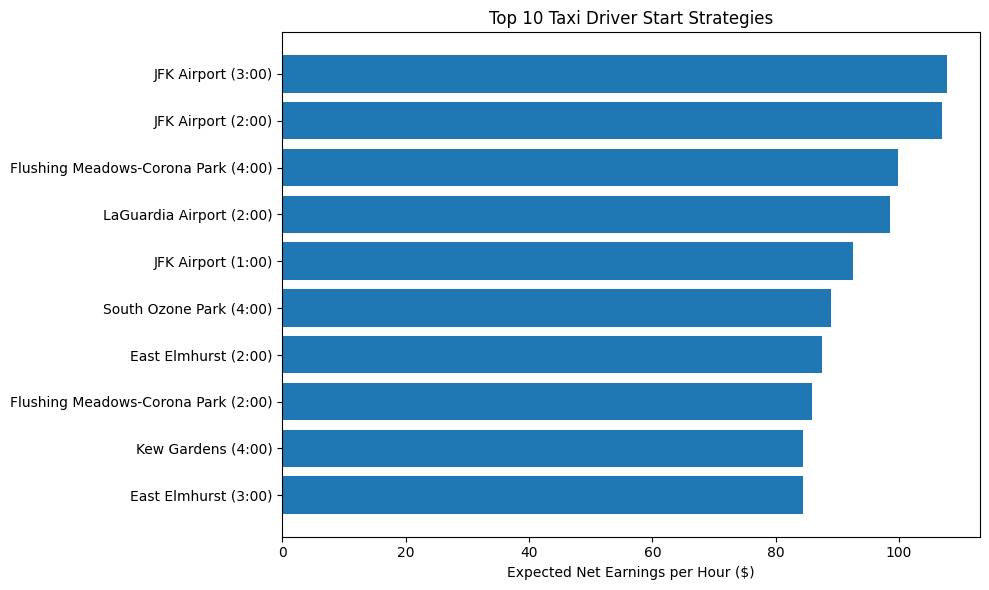

In [9]:
top10 = zone_hour_results.head(10).copy()

top10["label"] = (
    top10["Zone"] + " (" + top10["start_hour"].astype(str) + ":00)"
)

plt.figure(figsize=(10,6))

plt.barh(
    top10["label"],
    top10["expected_net_earnings_per_hour"]
)

plt.xlabel("Expected Net Earnings per Hour ($)")
plt.title("Top 10 Taxi Driver Start Strategies")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig("top10_start_strategies.png", dpi=300)

plt.show()

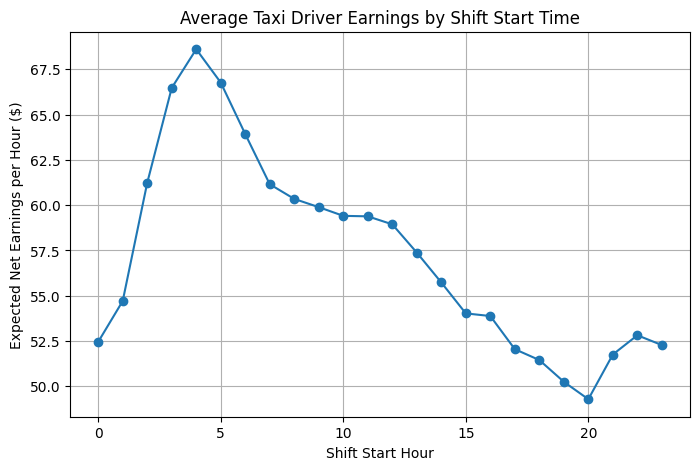

In [2]:
# expected earnings by start hour (line plot)

hour_summary = (
    zone_hour_results
    .groupby("start_hour")["expected_net_earnings_per_hour"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))
plt.plot(hour_summary.start_hour, hour_summary.expected_net_earnings_per_hour, marker="o")
plt.xlabel("Shift Start Hour")
plt.ylabel("Expected Net Earnings per Hour ($)")
plt.title("Average Taxi Driver Earnings by Shift Start Time")
plt.grid(True)
plt.show()

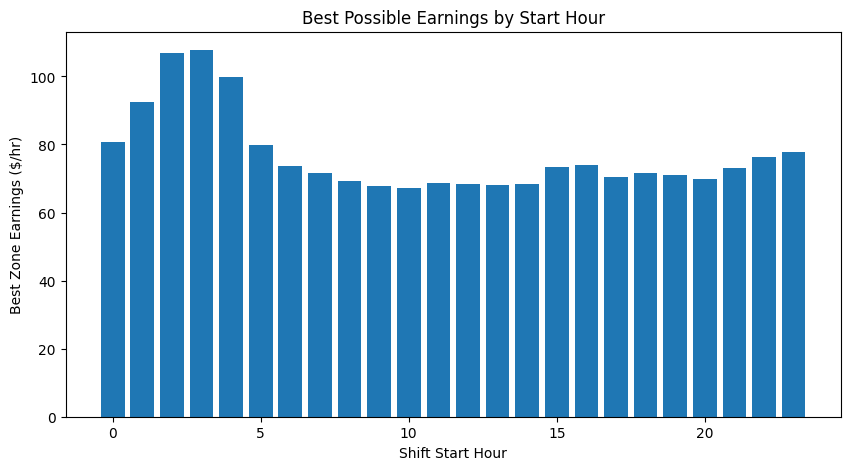

In [3]:
# best zone for each start hour

best_zone_each_hour = (
    zone_hour_results
    .sort_values("expected_net_earnings_per_hour", ascending=False)
    .groupby("start_hour")
    .first()
    .reset_index()
)

plt.figure(figsize=(10,5))
plt.bar(
    best_zone_each_hour.start_hour,
    best_zone_each_hour.expected_net_earnings_per_hour
)
plt.xlabel("Shift Start Hour")
plt.ylabel("Best Zone Earnings ($/hr)")
plt.title("Best Possible Earnings by Start Hour")
plt.show()

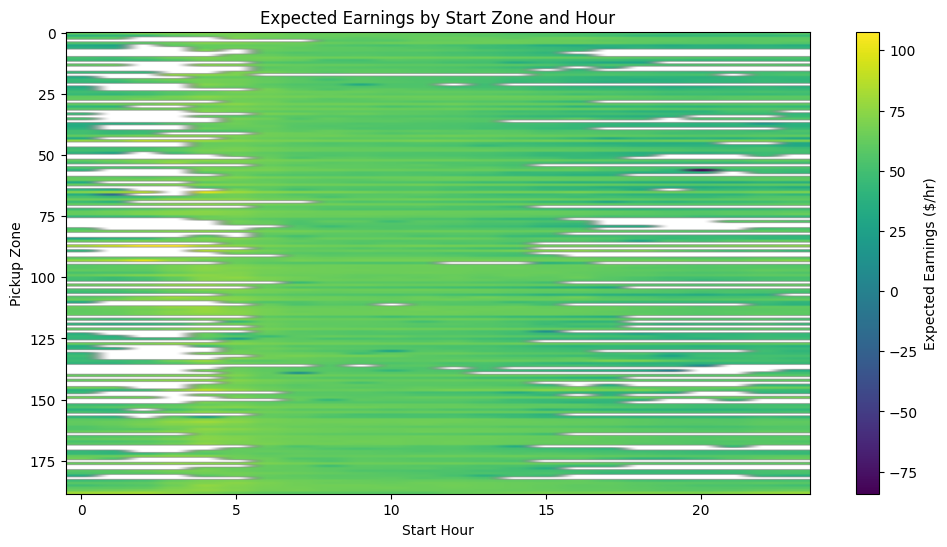

In [4]:
# zone x hour heatmap

heatmap_data = zone_hour_results.pivot_table(
    values="expected_net_earnings_per_hour",
    index="PULocationID",
    columns="start_hour"
)

plt.figure(figsize=(12,6))
plt.imshow(heatmap_data, aspect="auto")
plt.colorbar(label="Expected Earnings ($/hr)")
plt.xlabel("Start Hour")
plt.ylabel("Pickup Zone")
plt.title("Expected Earnings by Start Zone and Hour")
plt.show()

(np.float64(968223.7071977325),
 np.float64(1064935.8310982666),
 np.float64(140559.91157104896),
 np.float64(277226.55659260525))

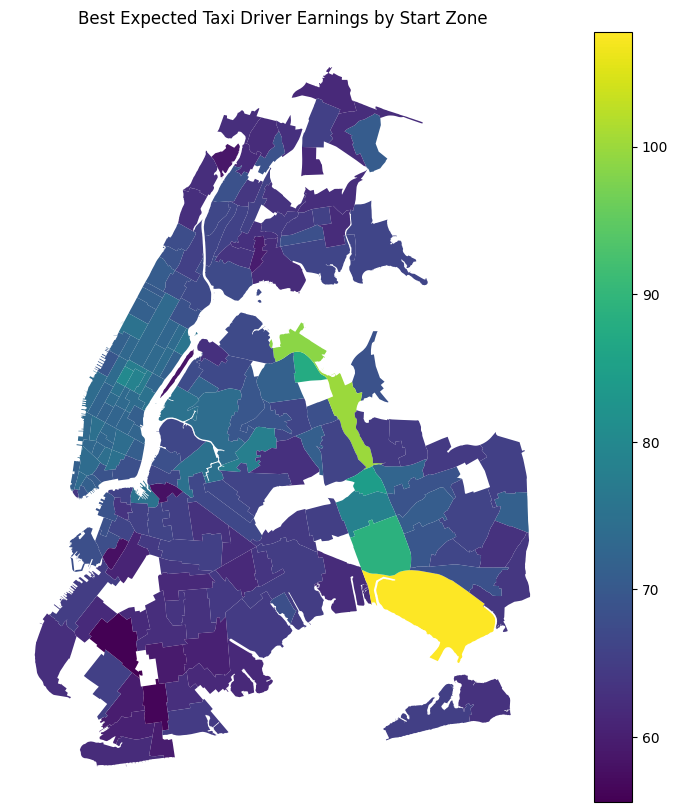

In [8]:
# map of best start zones

zones = gpd.read_file(raw_dir / "taxi_zones" / "taxi_zones.shp")

best_zone = zone_hour_results.sort_values(
    "expected_net_earnings_per_hour",
    ascending=False
).drop_duplicates("PULocationID")

map_data = zones.merge(
    best_zone,
    left_on="LocationID",
    right_on="PULocationID"
)

map_data.plot(
    column="expected_net_earnings_per_hour",
    cmap="viridis",
    legend=True,
    figsize=(10,10)
)

plt.title("Best Expected Taxi Driver Earnings by Start Zone")
plt.axis("off")